<a href="https://colab.research.google.com/github/ADHEERA12/Thiranx-DataScience-1/blob/main/FirstProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   Order_ID     Customer_Name     City     Category    Sales  Quantity  \
0         1     Samuel Bailey  Chennai      Grocery   1136.0     100.0   
1         2  Stephanie Palmer      NaN  Electronics   3655.0     100.0   
2         3      Andrew Mills  Chennai      Grocery   3370.0      17.0   
3         4      David Turner      NaN          NaN  99999.0     100.0   
4         5     Brian Hartman      NaN      Grocery      NaN       NaN   

   Order_Date  
0  2024-11-12  
1  2024-10-22  
2  2025-09-14  
3  2025-01-11  
4  2026-01-14  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       210 non-null    int64  
 1   Customer_Name  210 non-null    object 
 2   City           168 non-null    object 
 3   Category       171 non-null    object 
 4   Sales          138 non-null    float64
 5   Quantity     

/tmp/ipykernel_3491/2400081348.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3491/2400081348.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

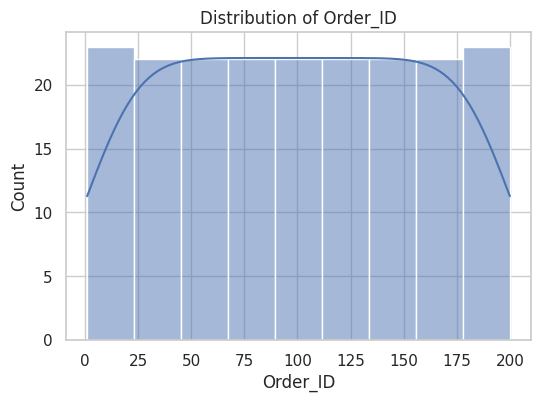

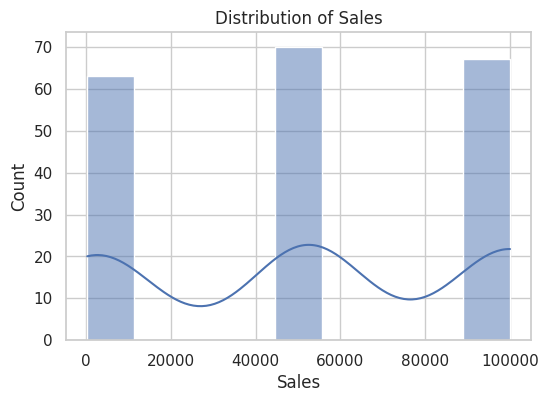

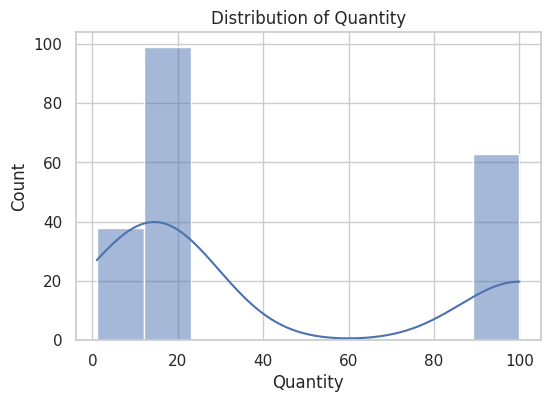

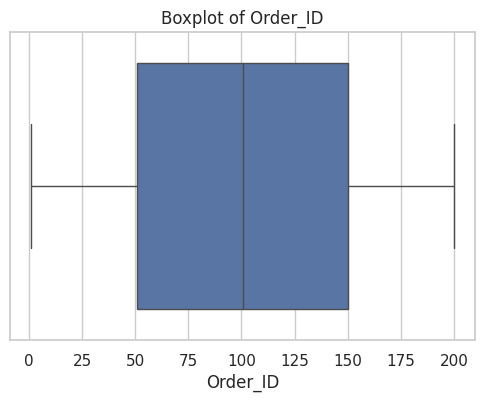

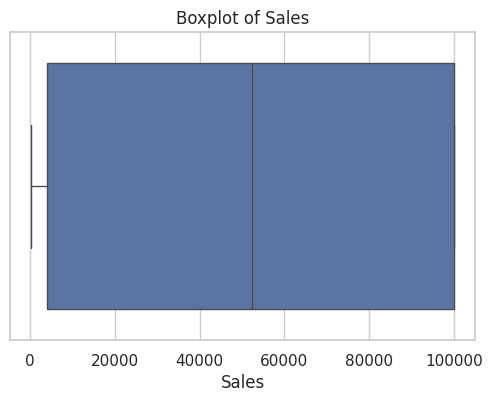

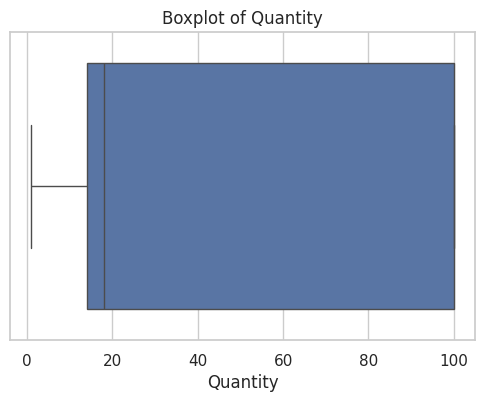

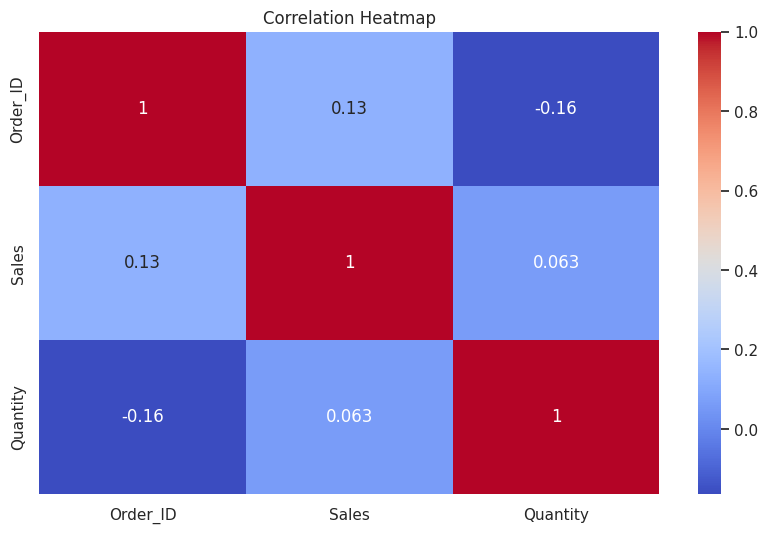

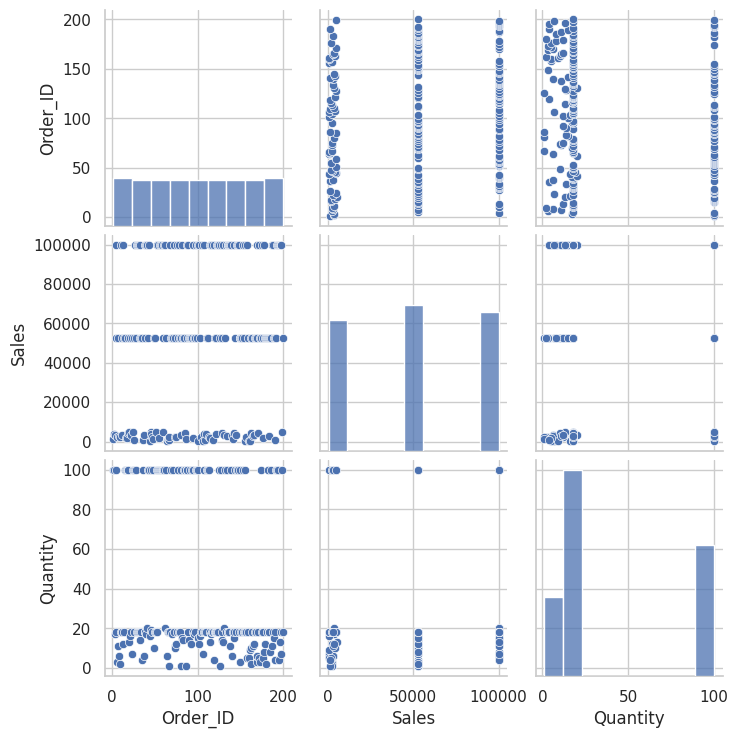


Sales by Category:
Category
Clothing       2100845.0
Electronics    2052230.0
Furniture      1896012.0
Grocery        4484994.0
Name: Sales, dtype: float64


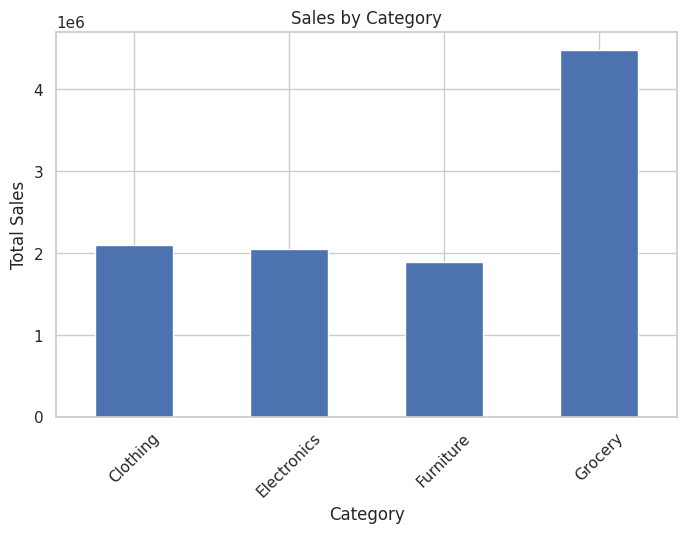


Cleaned dataset saved successfully!

Key Findings:
1. Missing values handled successfully
2. Duplicate rows removed
3. Outliers cleaned using IQR method
4. Correlation analysis completed
5. Visual insights generated using charts



In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization style
sns.set(style="whitegrid")

# ============================================
# STEP 2: Load Dataset
# ============================================

# Replace with your dataset path
df = pd.read_csv("/content/raw_dataset.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset info
print("\nDataset Info:")
print(df.info())


# STEP 3: Check Missing Values


print("\nMissing Values:")
print(df.isnull().sum())

# Fill numerical missing values with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())


# STEP 4: Remove Duplicate Rows


print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates removed.")
print("New Shape:", df.shape)


# STEP 5: Handle Outliers using IQR Method


def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

# Remove outliers from all numerical columns
for col in numeric_cols:
    df = remove_outliers_iqr(df, col)

print("\nShape after removing outliers:", df.shape)


# STEP 6: Basic Statistical Summary


print("\nStatistical Summary:")
print(df.describe())

# STEP 7: Data Visualization

# ---------- Histogram ----------
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# ---------- Boxplot ----------
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# ---------- Correlation Heatmap ----------
plt.figure(figsize=(10,6))

correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ---------- Pairplot ----------
sns.pairplot(df[numeric_cols])
plt.show()

if 'Category' in df.columns and 'Sales' in df.columns:

    category_sales = df.groupby('Category')['Sales'].sum()

    print("\nSales by Category:")
    print(category_sales)

    # Bar chart
    plt.figure(figsize=(8,5))
    category_sales.plot(kind='bar')

    plt.title("Sales by Category")
    plt.xlabel("Category")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)

    plt.show()



df.to_csv("cleaned_dataset.csv", index=False)

print("\nCleaned dataset saved successfully!")



print("""
Key Findings:
1. Missing values handled successfully
2. Duplicate rows removed
3. Outliers cleaned using IQR method
4. Correlation analysis completed
5. Visual insights generated using charts
""")